Importing

In [141]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [142]:
df = pd.read_csv("data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


create column "Country"

In [143]:
df["Country"]="ethiopia"

changing date

In [144]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change month to name

In [145]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [146]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [147]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [148]:
df = df.drop_duplicates()

describe 

In [149]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN


The dataset contains 4,108 observations from 2015 to 2026 with no missing values, indicating high data quality and completeness. The average temperature (T2M) is 16.1°C, with values ranging from 10.03°C to 21.53°C, showing a moderate and relatively stable climate. Maximum and minimum temperatures indicate a wider spread, with an average daily temperature range of 12.97°C, suggesting noticeable day–night variation. Precipitation (PRECTOTCORR) has a mean of 3.63 mm but a maximum of 82.3 mm, indicating a right-skewed distribution with occasional heavy rainfall events. Humidity (RH2M) averages 68.4% but varies widely (14.4% to 91.9%), reflecting changing atmospheric conditions. Wind speeds are generally low to moderate (mean ≈ 2.0 m/s), while surface pressure (PS) is highly stable with very little variation. Overall, the dataset reflects a moderate climate with stable temperatures, variable humidity, and irregular but sometimes intense precipitation, and it is well-prepared for further analysis due to the absence of missing data.

number of Nan

In [150]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [151]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [152]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [153]:
z_scores = np.abs(stats.zscore(df[cols]))

In [154]:
outliers_mask=(z_scores>3).any(axis=1)

In [155]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 132


Z-score analysis was performed on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) using a threshold of |Z| > 3 to identify extreme values. The analysis identified 132 rows as outliers, indicating a moderate presence of unusual observations in the dataset. These outliers are mainly linked to precipitation, wind speed, and occasional temperature or humidity extremes, which are expected to vary more in climate datasets. In a climatological context, these values may represent true extreme weather events rather than data errors, so they should generally be retained. However, to improve statistical stability and reduce the influence of extreme values, it is recommended to apply robust preprocessing techniques such as log transformation, capping (winsorization), or normalization during further analysis.

Handling missing values

In [156]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [157]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [158]:
df_clean = df[~outliers_mask].copy()

In [159]:
print(f"Cleaned rows:{len(df)}")

Cleaned rows:4108


In [160]:
df.to_csv("data/ethiopia_clean.csv", index=False)

In [161]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [162]:
print(df_clean.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date',
       'Month_Name'],
      dtype='str')


In [163]:
for col in df.columns:
    print(repr(col))


'YEAR'
'DOY'
'T2M'
'T2M_MAX'
'T2M_MIN'
'T2M_RANGE'
'PRECTOTCORR'
'RH2M'
'WS2M'
'WS2M_MAX'
'PS'
'QV2M'
'Country'
'Date'
'Month_Name'


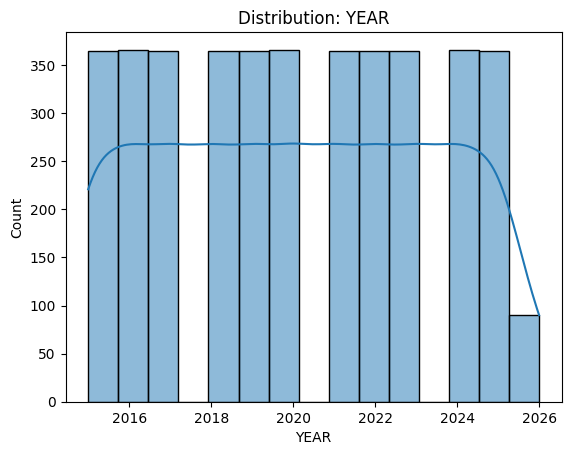

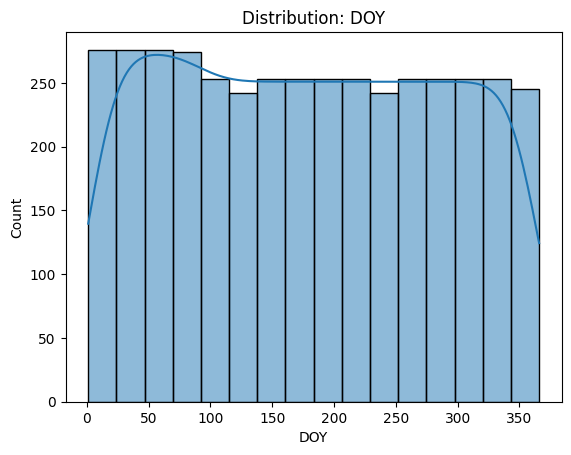

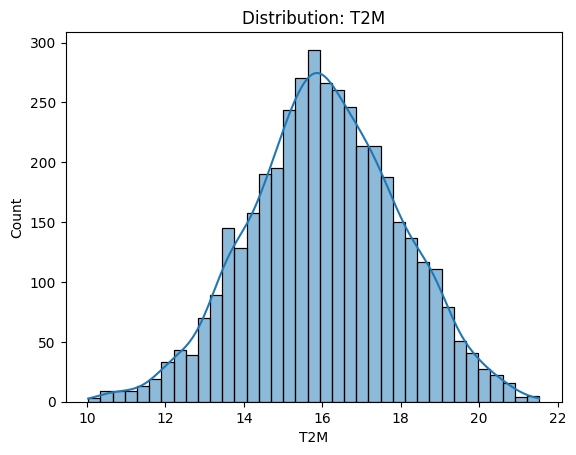

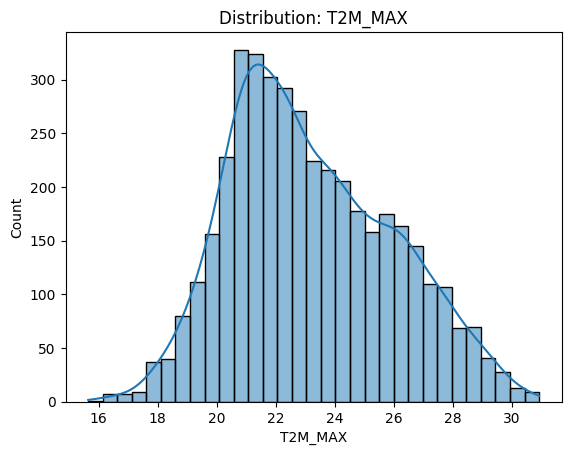

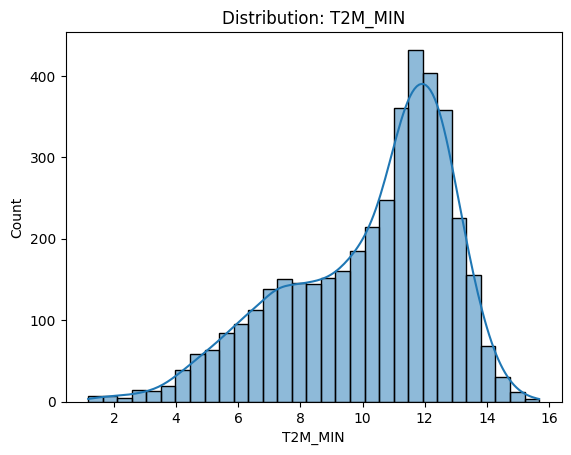

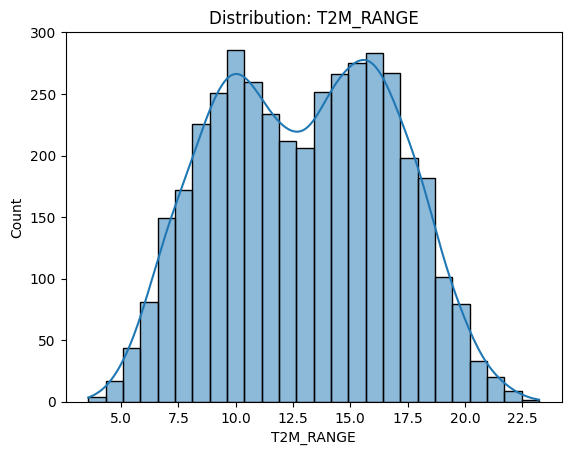

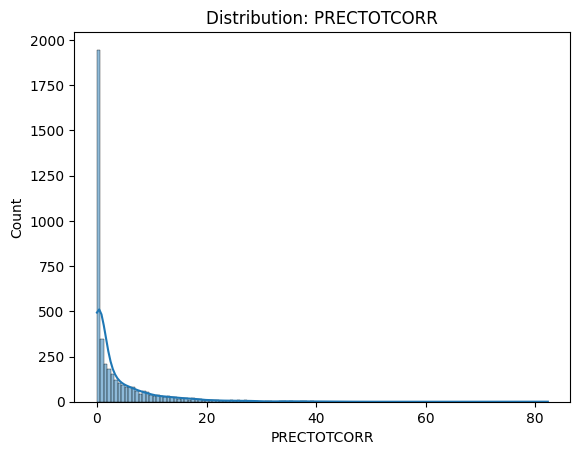

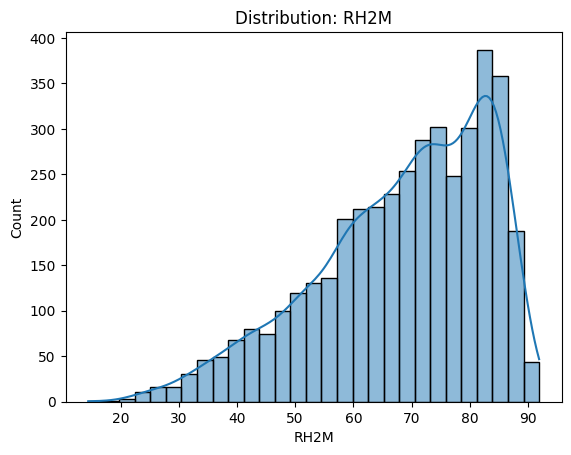

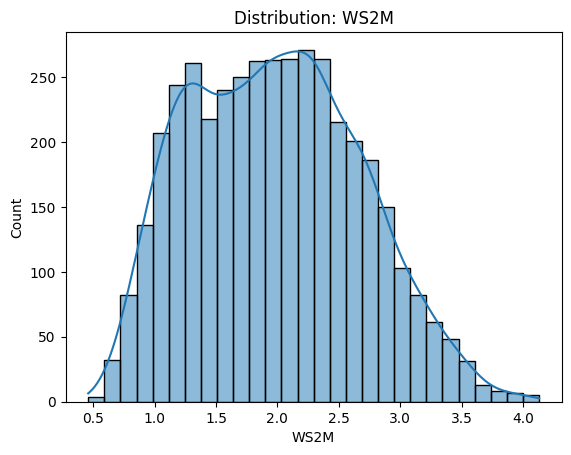

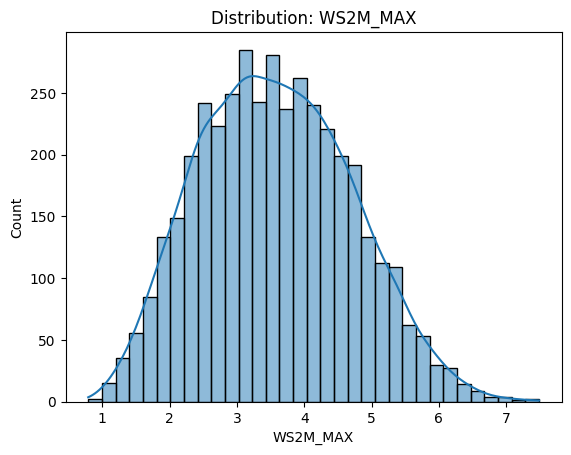

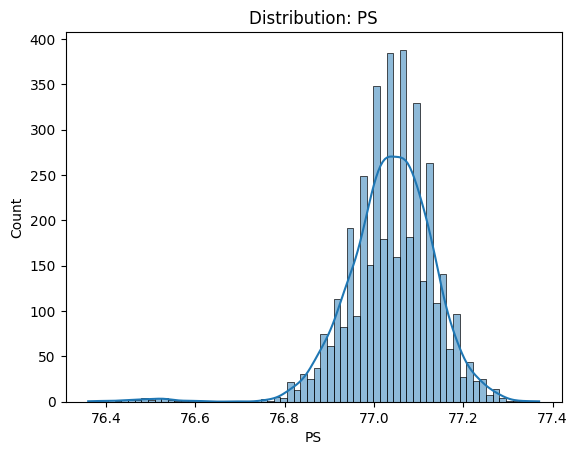

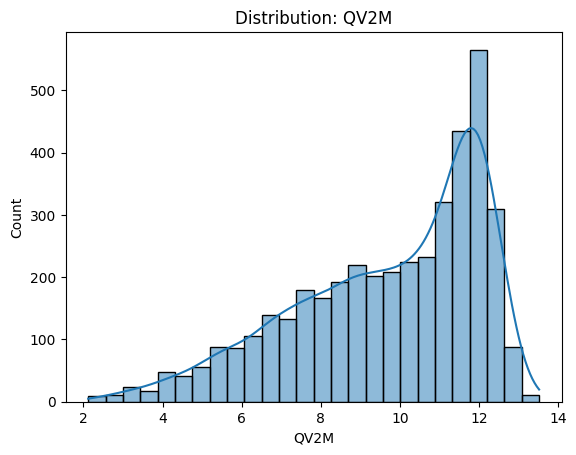

In [164]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    plt.figure()
    sns.histplot(df[c], kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

In [165]:

df_clean = df[~outliers_mask].copy()

Monthly average T2M

In [166]:

# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

In [167]:

monthly_t2m = df_clean["T2M"].resample("ME").mean()

Find warmest and coolest months

In [168]:

warmest_month = monthly_t2m.idxmax()
coolest_month = monthly_t2m.idxmin()
warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()


plot

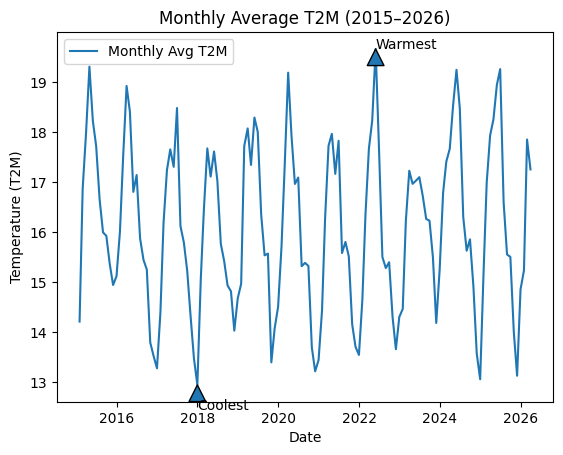

In [169]:
# Plot
plt.plot(monthly_t2m, label="Monthly Avg T2M")
# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_month, warmest_value),
             xytext=(warmest_month, warmest_value),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_month, coolest_value),
             xytext=(coolest_month, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

BAR chart for PRECTOTCORR

In [170]:
print(df_clean.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-01  2015    1  11.73    22.75     3.44      19.31          0.0  41.79   
2015-01-02  2015    2  12.30    24.01     4.09      19.92          0.0  33.29   
2015-01-03  2015    3  12.49    24.17     3.97      20.20          0.0  33.83   
2015-01-04  2015    4  14.08    23.78     6.90      16.88          0.0  38.84   
2015-01-05  2015    5  14.06    23.15     7.32      15.83          0.0  47.07   

            WS2M  WS2M_MAX     PS  QV2M   Country Month_Name  
Date                                                          
2015-01-01  2.73      5.07  77.13  4.00  ethiopia    January  
2015-01-02  2.39      4.19  77.14  3.35  ethiopia    January  
2015-01-03  1.77      2.76  77.11  3.43  ethiopia    January  
2015-01-04  0.87      1.28  77.07  4.60  ethiopia    January  
2015-01-05  1.34      2.14  77.01  5.58  ethiopia    J

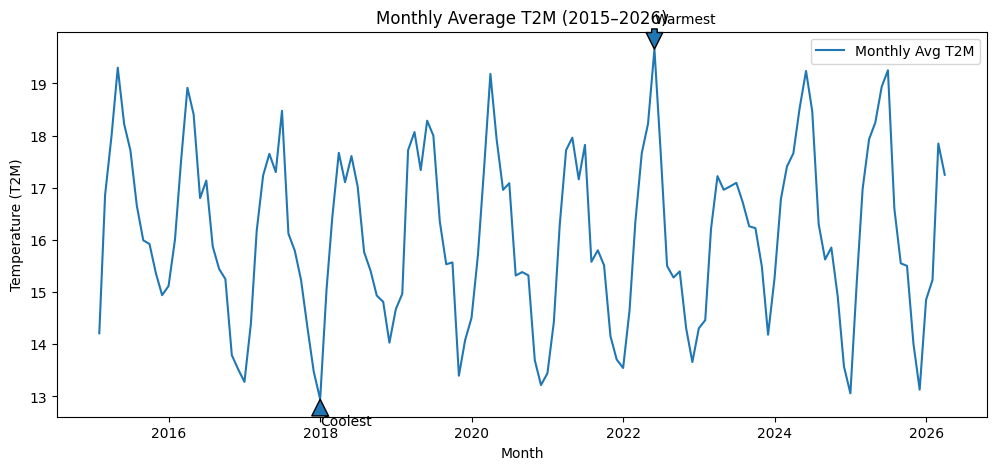

In [171]:


# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


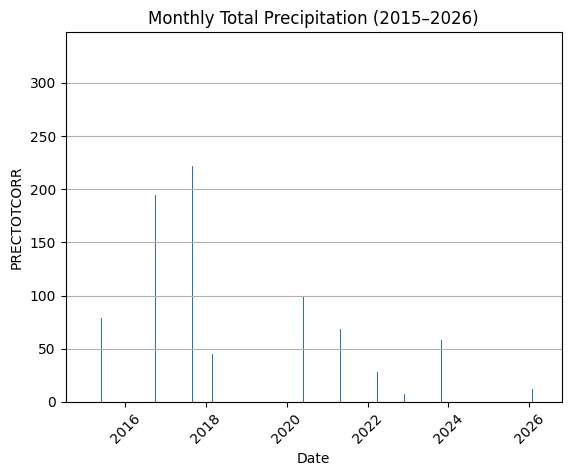

In [172]:
# Monthly average T2M
monthly_precip = df_clean["PRECTOTCORR"].resample("ME").sum()
plt.bar(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

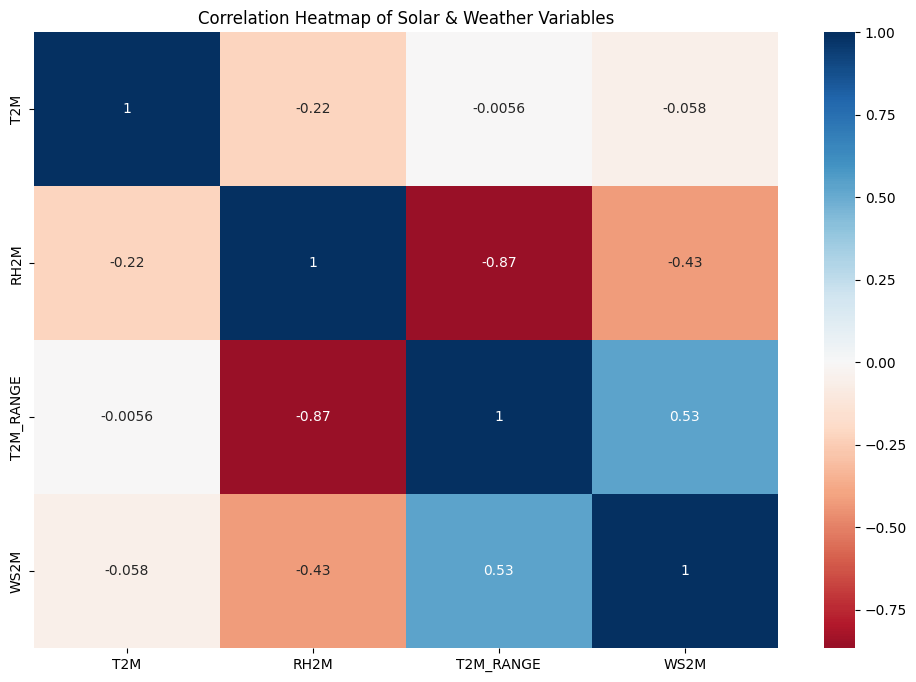

In [173]:

#selecting main columns for correlation
corr_cols = ['T2M', 'RH2M', 'T2M_RANGE', 'WS2M']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

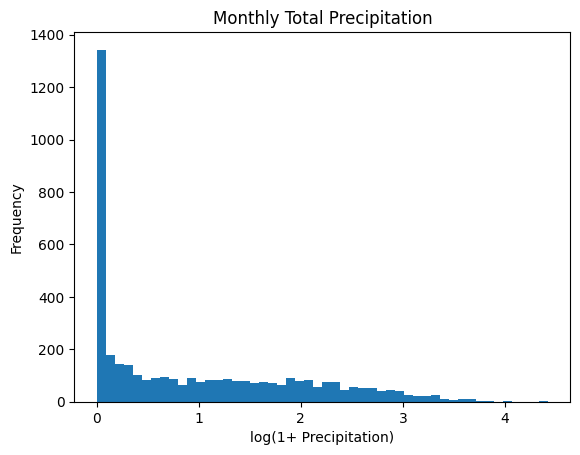

In [174]:


plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=50)
plt.title("Monthly Total Precipitation")
plt.xlabel("log(1+ Precipitation)")
plt.ylabel("Frequency")
plt.show()

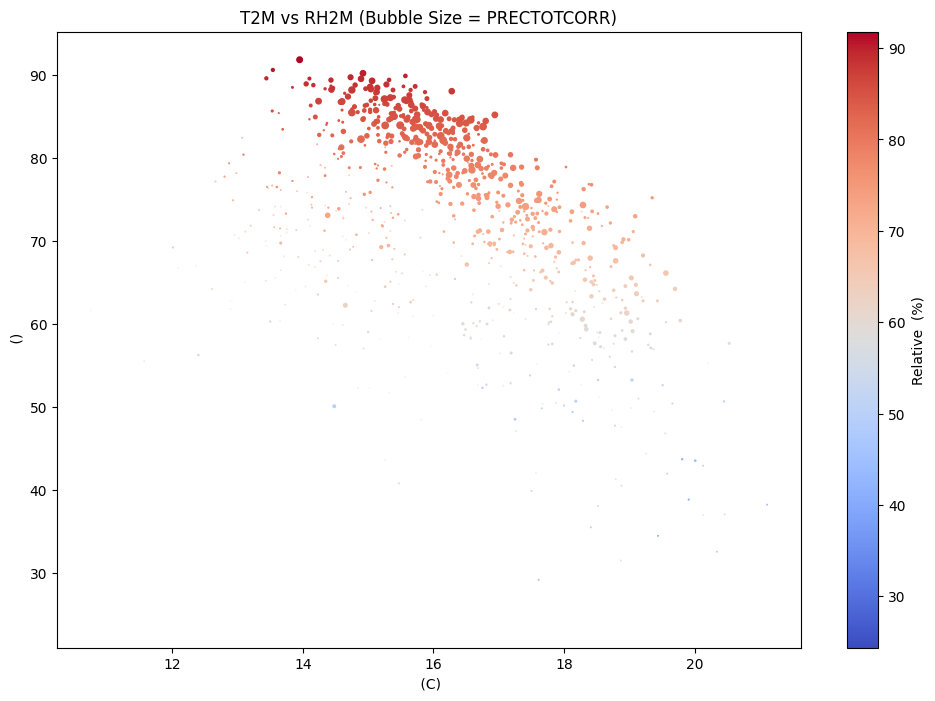

In [175]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['T2M'], sample_bubble['RH2M'], 
            s=sample_bubble['PRECTOTCORR'], # Size of bubble
            c=sample_bubble['RH2M'], # Color can also 
            cmap='coolwarm')

plt.title('T2M vs RH2M (Bubble Size = PRECTOTCORR)')
plt.xlabel(' (C)')
plt.ylabel(' ()')
plt.colorbar(label='Relative  (%)')
plt.show()
